# Autonomous NBV Inspection Policy: Comprehensive Parameter Matrix Benchmark Analysis

This notebook provides a comprehensive diagnostic, visual, and statistical evaluation of the Next-Best-View (NBV) inspection agent across the full operational parameter matrix (`benchmark_raw_data_matrix.csv`).

---

In [1]:
import os
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
from IPython.display import display, Markdown

warnings.filterwarnings("ignore")

# Configure premium publication plotting style
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "figure.titlesize": 14,
    "figure.dpi": 150,
    "savefig.dpi": 300,
})

POLICY_COLORS = {
    "PPO": "#1f77b4",     # Blue
    "Spiral": "#ff7f0e",  # Orange
    "Random": "#2ca02c",  # Green
}

---

## 1. Load and Preprocess Matrix Benchmark Data

We load the raw CSV, standardize all derived metrics (coverage percentage, fuel consumed percentage, mission time fraction, orbital radius), and index the 7 parameter matrix configurations.

In [2]:
matrix_csv_path = "artefacts/benchmark/benchmark_raw_data_matrix.csv"
fallback_csv_path = "artefacts/benchmark/benchmark_raw_data.csv"

if os.path.exists(matrix_csv_path):
    df = pd.read_csv(matrix_csv_path)
    print(f"Loaded matrix data from '{matrix_csv_path}': {len(df):,} records.")
elif os.path.exists(fallback_csv_path):
    df = pd.read_csv(fallback_csv_path)
    print(f"Matrix CSV not found. Loaded fallback data from '{fallback_csv_path}': {len(df):,} records.")
else:
    raise FileNotFoundError("No benchmark data CSV found in 'artefacts/benchmark/'. Please run benchmark.py first.")

# Standardize configuration columns if missing in legacy datasets
if "config_fuel_budget" not in df.columns:
    df["config_fuel_budget"] = 100.0
if "config_num_orbits" not in df.columns:
    df["config_num_orbits"] = 2.0
if "config_max_step" not in df.columns:
    df["config_max_step"] = 30
if "config_koz_radius" not in df.columns:
    df["config_koz_radius"] = 0.95

# Derived metrics
df["coverage_pct"] = df["coverage"] * 100.0
df["coverage_gain_pct"] = df["coverage_gain"] * 100.0
df["fuel_pct_consumed"] = df["fuel_consumed_fraction"] * 100.0

# Camera distance from origin (chief center)
if "viewpoint_distance" not in df.columns or df["viewpoint_distance"].isna().all():
    df["viewpoint_distance"] = np.sqrt(df["camera_x"]**2 + df["camera_y"]**2 + df["camera_z"]**2)

# Configuration labeling map
CONFIG_LABELS = {
    (100.0, 2.0, 30, 0.95): "InDist (100 m/s, 2 orbits, 30 steps)",
    (200.0, 2.0, 30, 0.95): "Budget-200 (200 m/s, 2 orbits, 30 steps)",
    (300.0, 3.0, 30, 0.95): "Budget-300 (300 m/s, 3 orbits, 30 steps)",
    (500.0, 5.0, 30, 0.95): "OOD-500-30 (500 m/s, 5 orbits, 30 steps)",
    (500.0, 5.0, 50, 0.95): "OOD-500-50 (500 m/s, 5 orbits, 50 steps)",
    (100.0, 2.0, 30, 0.85): "KOZ-0.85 (100 m/s, 2 orbits, KOZ Tight)",
    (100.0, 2.0, 30, 1.05): "KOZ-1.05 (100 m/s, 2 orbits, KOZ Wide)",
}

df["config_label"] = df.apply(
    lambda r: CONFIG_LABELS.get(
        (float(r["config_fuel_budget"]), float(r["config_num_orbits"]), int(r["config_max_step"]), float(r["config_koz_radius"])),
        f"Fuel {r['config_fuel_budget']}m, Orb {r['config_num_orbits']}, Step {r['config_max_step']}, KOZ {r['config_koz_radius']}"
    ),
    axis=1
)

# Extract terminal step for every unique episode
ep_group_cols = ["dataset_split", "policy", "model_name", "loop_id", "config_label"]
idx_final = df.groupby(ep_group_cols)["step"].idxmax()
df_final = df.loc[idx_final].copy()

print(f"Total Unique Evaluation Episodes: {len(df_final):,}")
print("Config breakdown:")
display(df_final["config_label"].value_counts().to_frame("Episode Count"))

Loaded matrix data from 'artefacts/benchmark/benchmark_raw_data_matrix.csv': 26,888 records.
Total Unique Evaluation Episodes: 1,536
Config breakdown:


,Episode Count
config_label,
"Budget-200 (200 m/s, 2 orbits, 30 steps)",192
"Budget-300 (300 m/s, 3 orbits, 30 steps)",192
"Fuel 100.0m, Orb 2.0, Step 10, KOZ 0.95",192
"Fuel 500.0m, Orb 5.0, Step 30, KOZ 0.85",192
"Fuel 500.0m, Orb 5.0, Step 30, KOZ 1.05",192
"InDist (100 m/s, 2 orbits, 30 steps)",192
"OOD-500-30 (500 m/s, 5 orbits, 30 steps)",192
"OOD-500-50 (500 m/s, 5 orbits, 50 steps)",192


---

## 2. Global Performance & Metric Tables

We compute clean, publication-ready performance tables (Mean $\pm$ Standard Deviation) for each split, configuration, and policy.

In [3]:
# 1. In-Distribution Performance Table
indist_final = df_final[df_final["config_label"] == "InDist (100 m/s, 2 orbits, 30 steps)"]
indist_summary = indist_final.groupby(["policy", "dataset_split"])["coverage_pct"].agg(["mean", "std", "count"]).round(2)
indist_summary["Formatted"] = indist_summary.apply(lambda r: f"{r['mean']:.2f} ± {r['std']:.2f}% (N={int(r['count'])})", axis=1)

print("=== In-Distribution Coverage Summary (100 m/s, 2 orbits) ===")
display(indist_summary["Formatted"].unstack("dataset_split")[["Train", "Val", "Test"]])

# 2. Complete Parameter Matrix Summary (Test Split)
test_final = df_final[df_final["dataset_split"] == "Test"]
test_matrix_summary = test_final.groupby(["config_label", "policy"])[["coverage_pct", "fuel_pct_consumed", "cumulative_dv", "step"]].agg({
    "coverage_pct": ["mean", "std"],
    "fuel_pct_consumed": "mean",
    "cumulative_dv": "mean",
    "step": "mean"
}).round(2)

test_matrix_summary.columns = [
    "Coverage Mean (%)", "Coverage Std (%)",
    "Fuel Consumed (%)", "Delta-v (m/s)", "Final Steps"
]

print("=== Test Split Performance Across All 7 Matrix Configurations ===")
display(test_matrix_summary)

=== In-Distribution Coverage Summary (100 m/s, 2 orbits) ===


dataset_split,Train,Val,Test
policy,,,
PPO,38.98 ± 13.67% (N=44),43.93 ± 15.68% (N=9),40.80 ± 11.55% (N=11)
Random,30.66 ± 11.23% (N=44),34.62 ± 8.58% (N=9),37.43 ± 6.56% (N=11)
Spiral,37.36 ± 11.35% (N=44),40.42 ± 14.11% (N=9),34.91 ± 5.91% (N=11)


=== Test Split Performance Across All 7 Matrix Configurations ===


Coverage Mean (%)  \
config_label                             policy                      
Budget-200 (200 m/s, 2 orbits, 30 steps) PPO                 44.99   
                                         Random              36.31   
                                         Spiral              65.05   
Budget-300 (300 m/s, 3 orbits, 30 steps) PPO                 45.46   
                                         Random              38.25   
                                         Spiral              72.38   
Fuel 100.0m, Orb 2.0, Step 10, KOZ 0.95  PPO                 39.50   
                                         Random              37.89   
                                         Spiral              56.23   
Fuel 500.0m, Orb 5.0, Step 30, KOZ 0.85  PPO                 48.45   
                                         Random              37.17   
                                         Spiral              72.69   
Fuel 500.0m, Orb 5.0, Step 30, KOZ 1.05  PPO                 45.56   
                                         Random              38.60   
                                         Spiral              72.69   
InDist (100 m/s, 2 orbits, 30 steps)     PPO                 40.80   
                                         Random              37.43   
                                         Spiral              34.91   
OOD-500-30 (500 m/s, 5 orbits, 30 steps) PPO                 49.48   
                                         Random              33.90   
                                         Spiral              72.69   
OOD-500-50 (500 m/s, 5 orbits, 50 steps) PPO                 51.74   
                                         Random              40.76   
                                         Spiral              74.52   

                                                 Coverage Std (%)  \
config_label                             policy                     
Budget-200 (200 m/s, 2 orbits, 30 steps) PPO                 9.59   
                                         Random              7.85   
                                         Spiral              5.22   
Budget-300 (300 m/s, 3 orbits, 30 steps) PPO                10.14   
                                         Random             10.12   
                                         Spiral              5.31   
Fuel 100.0m, Orb 2.0, Step 10, KOZ 0.95  PPO                 9.60   
                                         Random             14.58   
                                         Spiral              7.26   
Fuel 500.0m, Orb 5.0, Step 30, KOZ 0.85  PPO                12.63   
                                         Random             13.13   
                                         Spiral              4.85   
Fuel 500.0m, Orb 5.0, Step 30, KOZ 1.05  PPO                12.23   
                                         Random              6.23   
                                         Spiral              4.85   
InDist (100 m/s, 2 orbits, 30 steps)     PPO                11.55   
                                         Random              6.56   
                                         Spiral              5.91   
OOD-500-30 (500 m/s, 5 orbits, 30 steps) PPO                13.04   
                                         Random             11.23   
                                         Spiral              4.85   
OOD-500-50 (500 m/s, 5 orbits, 50 steps) PPO                12.50   
                                         Random             13.41   
                                         Spiral              4.64   

                                                 Fuel Consumed (%)  \
config_label                             policy                      
Budget-200 (200 m/s, 2 orbits, 30 steps) PPO                104.21   
                                         Random              18.91   
                                         Spiral             100.40   
Budget-300 (300 m/s, 3 orbits, 30 steps) PPO                102.17   
             

---

## 3. Step-by-Step Trajectory Dynamics (Min-Max Bands & Spread)

These plots display the step-by-step surface coverage accumulation, cumulative fuel consumption, and mission duration with shaded min-max spread across all evaluated satellite models.

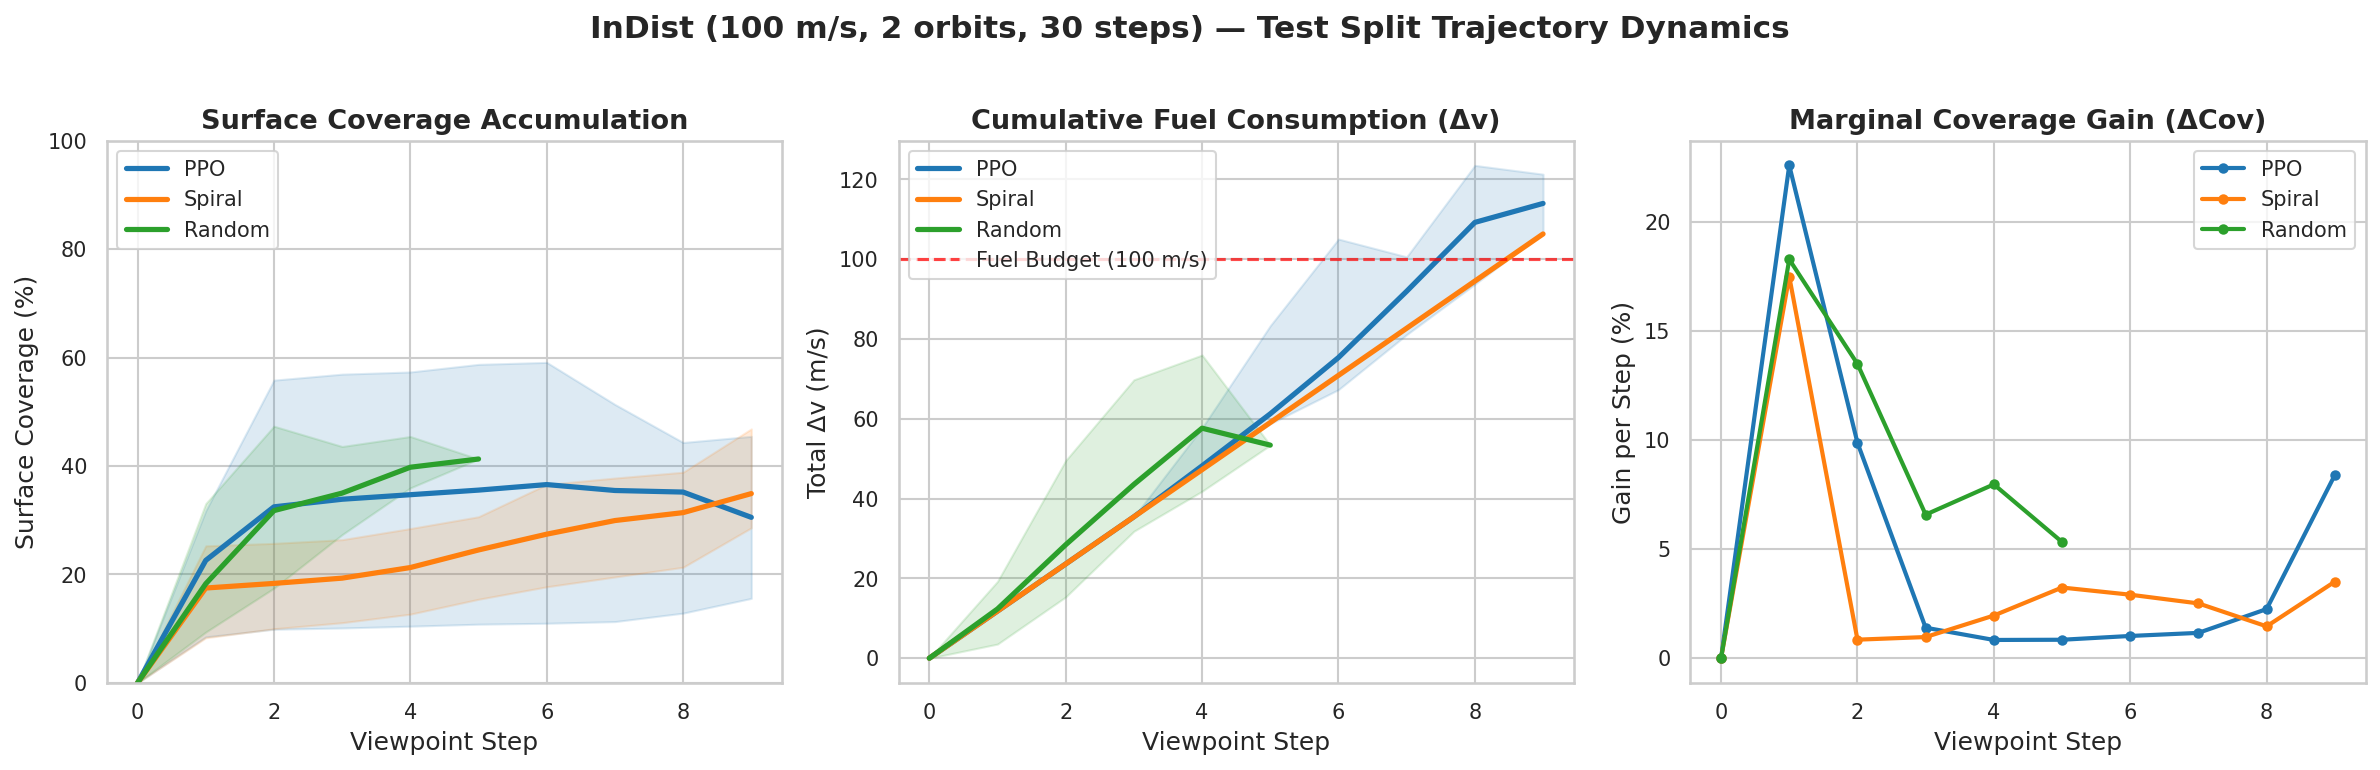

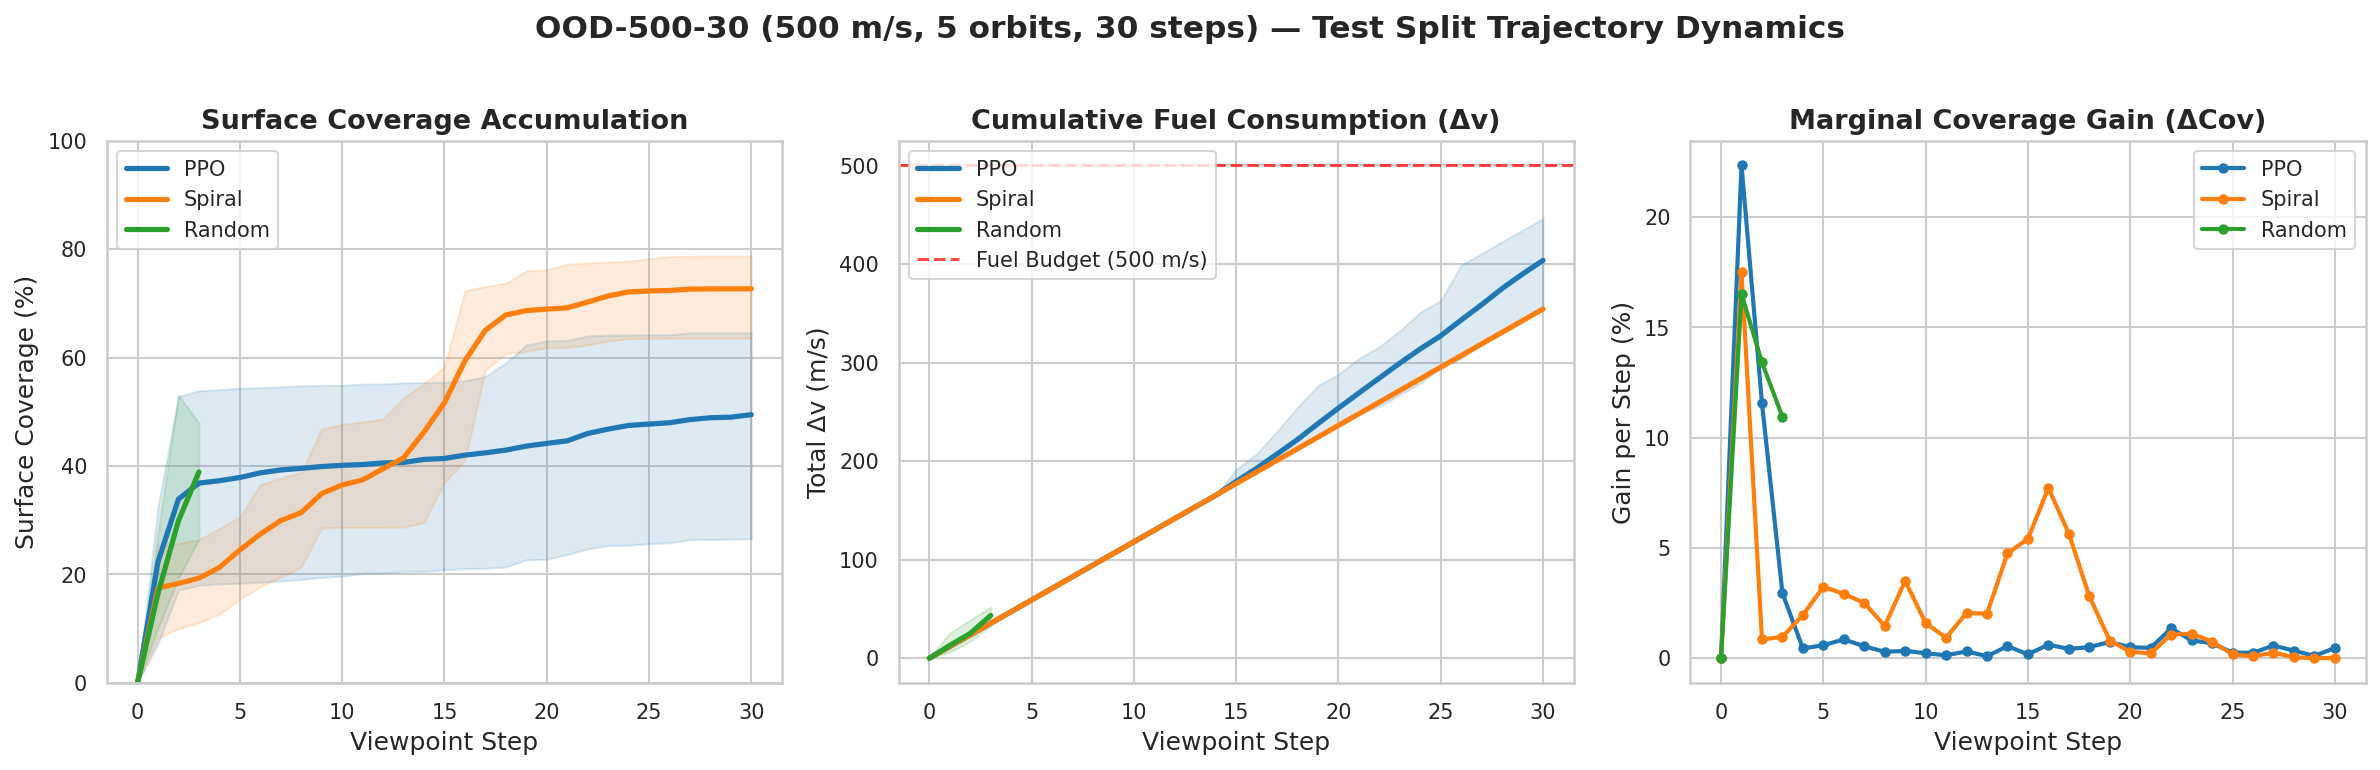

In [4]:
def plot_step_metric_dynamics(df_data, config_name, split_name="Test", figsize=(16, 5)):
    subset = df_data[(df_data["config_label"] == config_name) & (df_data["dataset_split"] == split_name)]
    if subset.empty:
        print(f"No data for {config_name} on {split_name} split.")
        return
        
    fig, axes = plt.subplots(1, 3, figsize=figsize)
    
    policies = [p for p in ["PPO", "Spiral", "Random"] if p in subset["policy"].unique()]
    
    # Panel 1: Surface Coverage Accumulation
    ax1 = axes[0]
    for pol in policies:
        pol_sub = subset[subset["policy"] == pol]
        stats = pol_sub.groupby("step")["coverage_pct"].agg(["mean", "min", "max"]).reset_index()
        color = POLICY_COLORS.get(pol, "gray")
        ax1.plot(stats["step"], stats["mean"], label=f"{pol}", color=color, linewidth=2.5)
        ax1.fill_between(stats["step"], stats["min"], stats["max"], color=color, alpha=0.15)
        
    ax1.set_title("Surface Coverage Accumulation", fontweight="bold")
    ax1.set_xlabel("Viewpoint Step")
    ax1.set_ylabel("Surface Coverage (%)")
    ax1.set_ylim(0, 100)
    ax1.legend(loc="upper left")
    
    # Panel 2: Cumulative Fuel Consumption (Delta-v)
    ax2 = axes[1]
    fuel_budget = subset["config_fuel_budget"].iloc[0]
    for pol in policies:
        pol_sub = subset[subset["policy"] == pol]
        stats = pol_sub.groupby("step")["cumulative_dv"].agg(["mean", "min", "max"]).reset_index()
        color = POLICY_COLORS.get(pol, "gray")
        ax2.plot(stats["step"], stats["mean"], label=f"{pol}", color=color, linewidth=2.5)
        ax2.fill_between(stats["step"], stats["min"], stats["max"], color=color, alpha=0.15)
        
    ax2.axhline(fuel_budget, color="red", linestyle="--", alpha=0.7, label=f"Fuel Budget ({fuel_budget:.0f} m/s)")
    ax2.set_title("Cumulative Fuel Consumption (Δv)", fontweight="bold")
    ax2.set_xlabel("Viewpoint Step")
    ax2.set_ylabel("Total Δv (m/s)")
    ax2.legend(loc="upper left")
    
    # Panel 3: Marginal Coverage Gain per Step
    ax3 = axes[2]
    for pol in policies:
        pol_sub = subset[subset["policy"] == pol]
        stats = pol_sub.groupby("step")["coverage_gain_pct"].mean().reset_index()
        color = POLICY_COLORS.get(pol, "gray")
        ax3.plot(stats["step"], stats["coverage_gain_pct"], label=f"{pol}", color=color, linewidth=2.0, marker="o", markersize=4)
        
    ax3.set_title("Marginal Coverage Gain (ΔCov)", fontweight="bold")
    ax3.set_xlabel("Viewpoint Step")
    ax3.set_ylabel("Gain per Step (%)")
    ax3.legend(loc="upper right")
    
    plt.suptitle(f"{config_name} — {split_name} Split Trajectory Dynamics", fontsize=15, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()

# 1. In-Distribution Dynamics (Test Set)
plot_step_metric_dynamics(df, "InDist (100 m/s, 2 orbits, 30 steps)", "Test")

# 2. Out-of-Distribution Dynamics (Test Set)
plot_step_metric_dynamics(df, "OOD-500-30 (500 m/s, 5 orbits, 30 steps)", "Test")

---

## 4. Operational Budget Scaling Sweep

We analyze how agent performance and heuristic baselines scale across the budget continuum: 00\,	ext{m/s}$ (2 orbits) $	o$ 00\,	ext{m/s}$ (2 orbits) $	o$ 00\,	ext{m/s}$ (3 orbits) $	o$ 00\,	ext{m/s}$ (5 orbits).

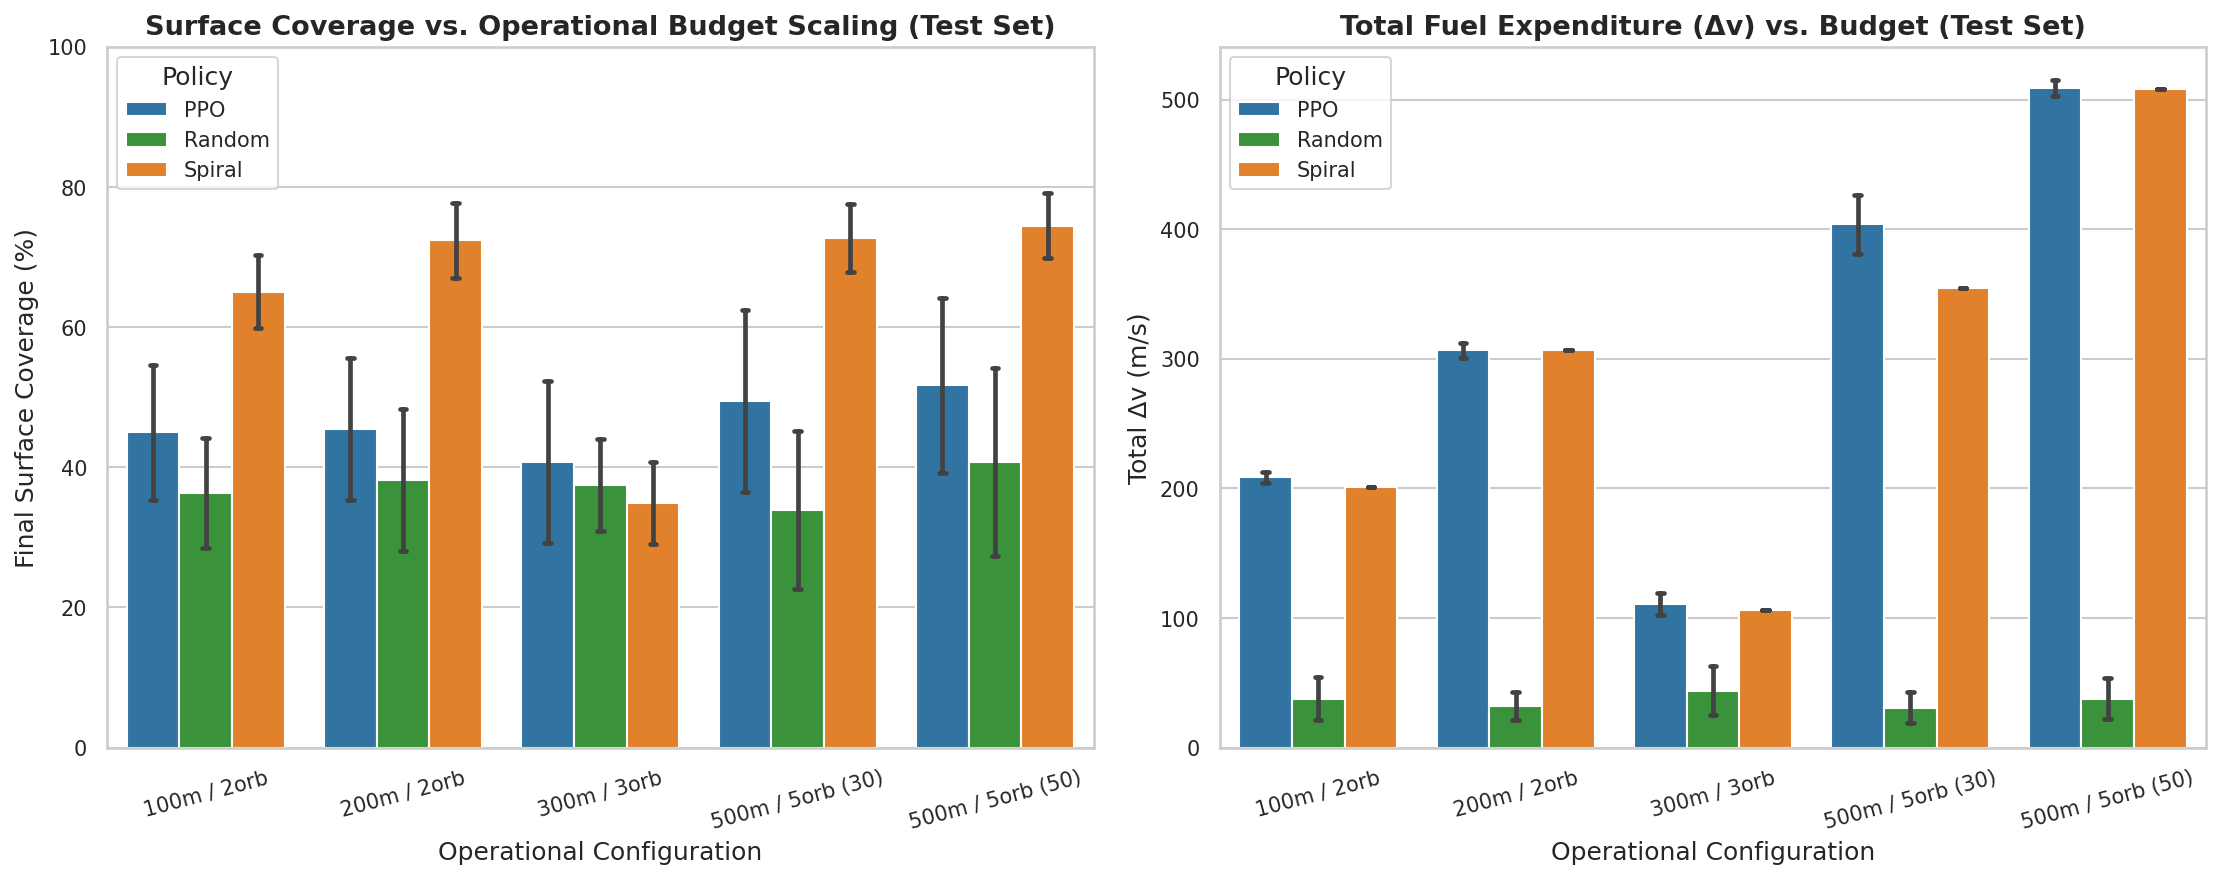

In [5]:
sweep_configs = [
    "InDist (100 m/s, 2 orbits, 30 steps)",
    "Budget-200 (200 m/s, 2 orbits, 30 steps)",
    "Budget-300 (300 m/s, 3 orbits, 30 steps)",
    "OOD-500-30 (500 m/s, 5 orbits, 30 steps)",
    "OOD-500-50 (500 m/s, 5 orbits, 50 steps)",
]

sweep_data = df_final[(df_final["config_label"].isin(sweep_configs)) & (df_final["dataset_split"] == "Test")]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Panel 1: Final Coverage vs. Budget Configuration
ax1 = axes[0]
sns.barplot(
    data=sweep_data, 
    x="config_label", 
    y="coverage_pct", 
    hue="policy", 
    palette=POLICY_COLORS, 
    ax=ax1, 
    ci="sd", 
    capsize=0.1
)
ax1.set_title("Surface Coverage vs. Operational Budget Scaling (Test Set)", fontweight="bold")
ax1.set_xlabel("Operational Configuration")
ax1.set_ylabel("Final Surface Coverage (%)")
ax1.set_xticklabels(["100m / 2orb", "200m / 2orb", "300m / 3orb", "500m / 5orb (30)", "500m / 5orb (50)"], rotation=15)
ax1.set_ylim(0, 100)
ax1.legend(title="Policy", loc="upper left")

# Panel 2: Total Delta-v Consumed vs. Fuel Budget
ax2 = axes[1]
sns.barplot(
    data=sweep_data, 
    x="config_label", 
    y="cumulative_dv", 
    hue="policy", 
    palette=POLICY_COLORS, 
    ax=ax2, 
    ci="sd", 
    capsize=0.1
)
ax2.set_title("Total Fuel Expenditure (Δv) vs. Budget (Test Set)", fontweight="bold")
ax2.set_xlabel("Operational Configuration")
ax2.set_ylabel("Total Δv (m/s)")
ax2.set_xticklabels(["100m / 2orb", "200m / 2orb", "300m / 3orb", "500m / 5orb (30)", "500m / 5orb (50)"], rotation=15)
ax2.legend(title="Policy", loc="upper left")

plt.tight_layout()
plt.show()

---

## 5. Safety Standoff (KOZ Radius) Sensitivity

We evaluate how Keep-Out Zone standoff radius variations ({	ext{koz}} \in \{0.85, 0.95, 1.05\}$) affect path planning and final coverage.

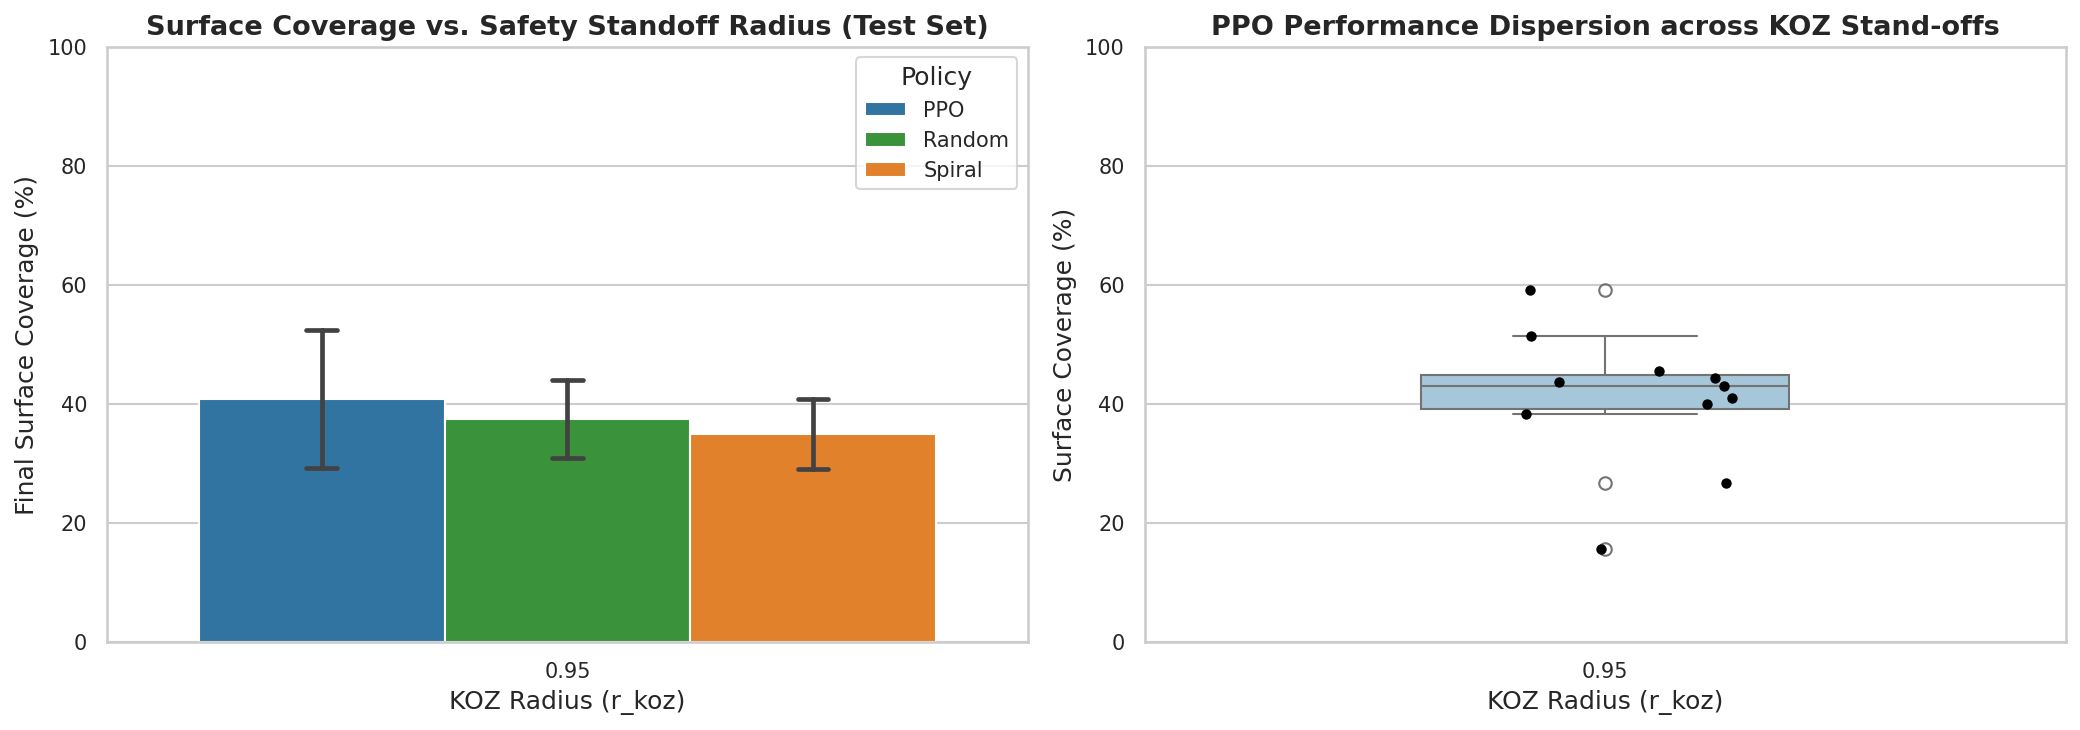

In [6]:
koz_configs = [
    "KOZ-0.85 (100 m/s, 2 orbits, KOZ Tight)",
    "InDist (100 m/s, 2 orbits, 30 steps)",
    "KOZ-1.05 (100 m/s, 2 orbits, KOZ Wide)",
]

koz_data = df_final[(df_final["config_label"].isin(koz_configs)) & (df_final["dataset_split"] == "Test")].copy()
koz_data["koz_radius_val"] = koz_data["config_koz_radius"].astype(str)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: Barplot of Coverage vs KOZ Radius
ax1 = axes[0]
sns.barplot(
    data=koz_data,
    x="koz_radius_val",
    y="coverage_pct",
    hue="policy",
    palette=POLICY_COLORS,
    ax=ax1,
    ci="sd",
    capsize=0.1
)
ax1.set_title("Surface Coverage vs. Safety Standoff Radius (Test Set)", fontweight="bold")
ax1.set_xlabel("KOZ Radius (r_koz)")
ax1.set_ylabel("Final Surface Coverage (%)")
ax1.set_ylim(0, 100)
ax1.legend(title="Policy", loc="upper right")

# Panel 2: Distribution Boxplot
ax2 = axes[1]
sns.boxplot(
    data=koz_data[koz_data["policy"] == "PPO"],
    x="koz_radius_val",
    y="coverage_pct",
    palette=["#9ecae1", "#4292c6", "#08519c"],
    ax=ax2,
    width=0.4
)
sns.stripplot(
    data=koz_data[koz_data["policy"] == "PPO"],
    x="koz_radius_val",
    y="coverage_pct",
    color="black",
    size=5,
    jitter=0.15,
    ax=ax2
)
ax2.set_title("PPO Performance Dispersion across KOZ Stand-offs", fontweight="bold")
ax2.set_xlabel("KOZ Radius (r_koz)")
ax2.set_ylabel("Surface Coverage (%)")
ax2.set_ylim(0, 100)

plt.tight_layout()
plt.show()

---

## 6. Pareto Frontiers & Resource Efficiency Trade-offs

We plot **Surface Coverage (%) vs. Fuel Consumed ($\Delta v$)** and **Surface Coverage (%) vs. Mission Time** to visualize Pareto efficiency.

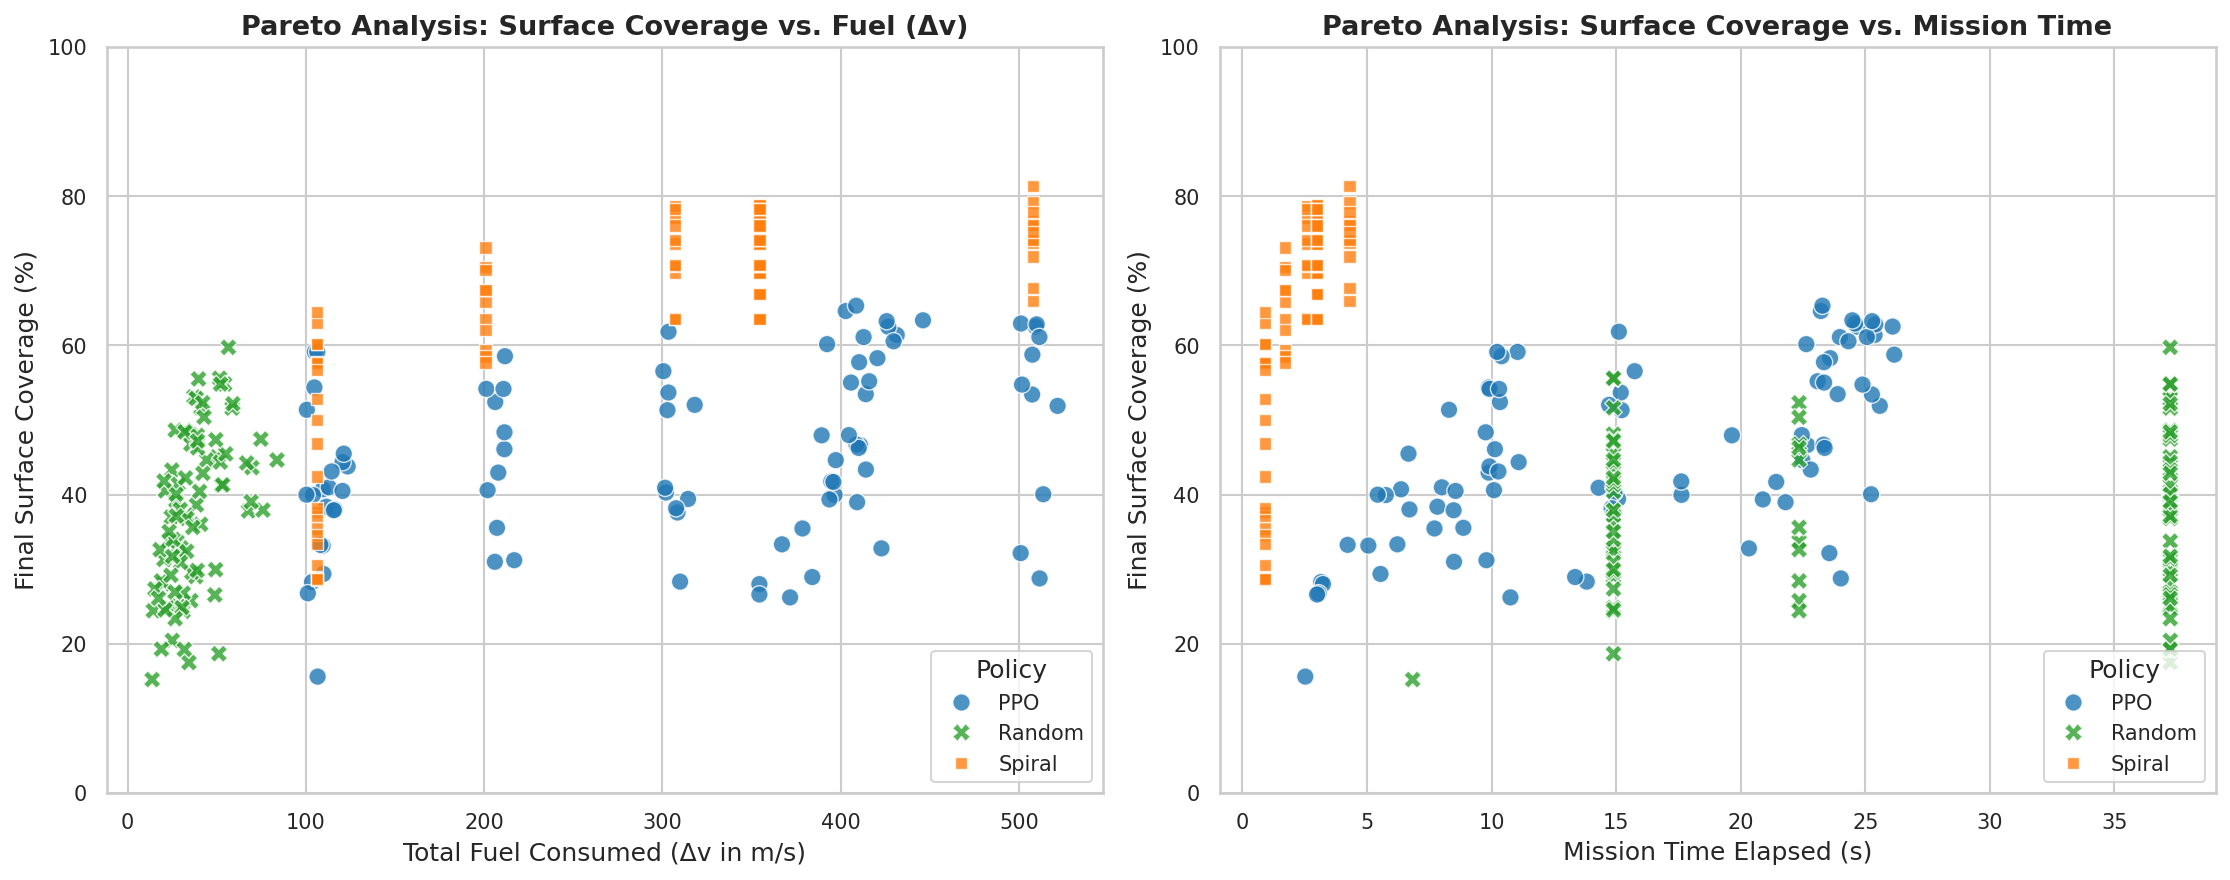

=== Resource Efficiency Metric (Coverage % gained per 100 m/s Delta-v) ===


policy,PPO,Random,Spiral
config_label,,,
"Budget-200 (200 m/s, 2 orbits, 30 steps)",21.61,109.76,32.40
"Budget-300 (300 m/s, 3 orbits, 30 steps)",14.85,125.39,23.57
"Fuel 100.0m, Orb 2.0, Step 10, KOZ 0.95",36.10,97.87,52.90
"Fuel 500.0m, Orb 5.0, Step 30, KOZ 0.85",11.86,100.89,20.51
"Fuel 500.0m, Orb 5.0, Step 30, KOZ 1.05",11.28,119.49,20.51
"InDist (100 m/s, 2 orbits, 30 steps)",36.94,98.41,32.84
"OOD-500-30 (500 m/s, 5 orbits, 30 steps)",12.19,116.91,20.51
"OOD-500-50 (500 m/s, 5 orbits, 50 steps)",10.17,115.15,14.67


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Panel 1: Coverage vs Total Delta-v Consumed
ax1 = axes[0]
sns.scatterplot(
    data=test_final,
    x="cumulative_dv",
    y="coverage_pct",
    hue="policy",
    style="policy",
    palette=POLICY_COLORS,
    s=70,
    alpha=0.8,
    ax=ax1
)
ax1.set_title("Pareto Analysis: Surface Coverage vs. Fuel (Δv)", fontweight="bold")
ax1.set_xlabel("Total Fuel Consumed (Δv in m/s)")
ax1.set_ylabel("Final Surface Coverage (%)")
ax1.set_ylim(0, 100)
ax1.legend(title="Policy", loc="lower right")

# Panel 2: Coverage vs Mission Time Elapsed
ax2 = axes[1]
sns.scatterplot(
    data=test_final,
    x="mission_time",
    y="coverage_pct",
    hue="policy",
    style="policy",
    palette=POLICY_COLORS,
    s=70,
    alpha=0.8,
    ax=ax2
)
ax2.set_title("Pareto Analysis: Surface Coverage vs. Mission Time", fontweight="bold")
ax2.set_xlabel("Mission Time Elapsed (s)")
ax2.set_ylabel("Final Surface Coverage (%)")
ax2.set_ylim(0, 100)
ax2.legend(title="Policy", loc="lower right")

plt.tight_layout()
plt.show()

# Resource efficiency metric: Coverage % per 100 m/s Delta-v
test_final["fuel_efficiency"] = test_final["coverage_pct"] / np.maximum(test_final["cumulative_dv"], 1.0) * 100.0
eff_summary = test_final.groupby(["config_label", "policy"])["fuel_efficiency"].mean().round(2).unstack("policy")
print("=== Resource Efficiency Metric (Coverage % gained per 100 m/s Delta-v) ===")
display(eff_summary)

---

## 7. Distributional & Spacecraft-by-Spacecraft Heatmaps

We inspect policy performance across each individual spacecraft CAD model (e.g. Chandra, Clementine, MRO, Apollo-Soyuz, Terra, Stardust).

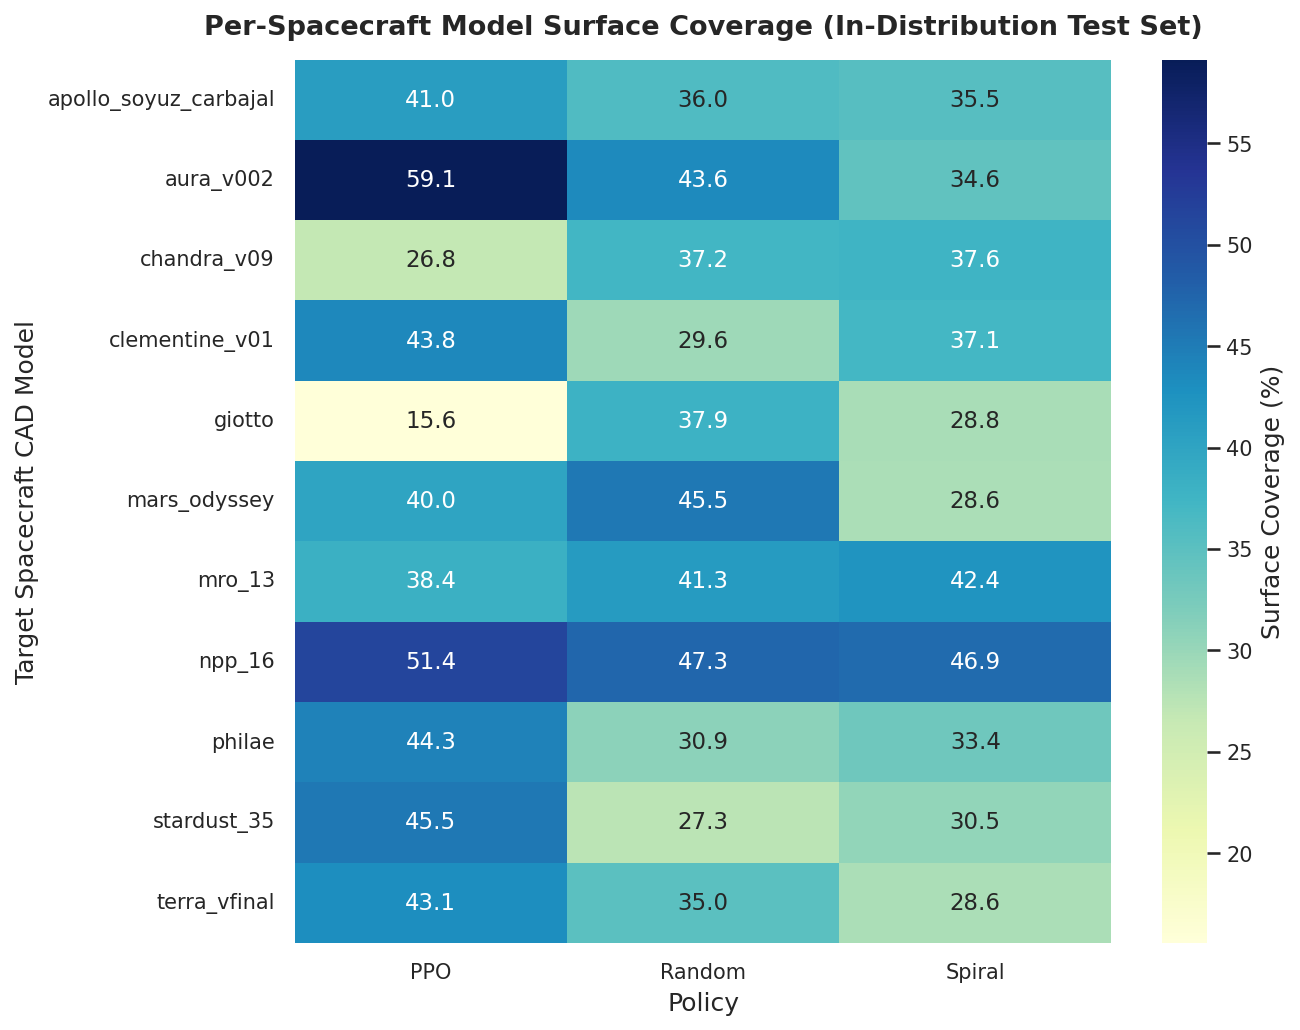

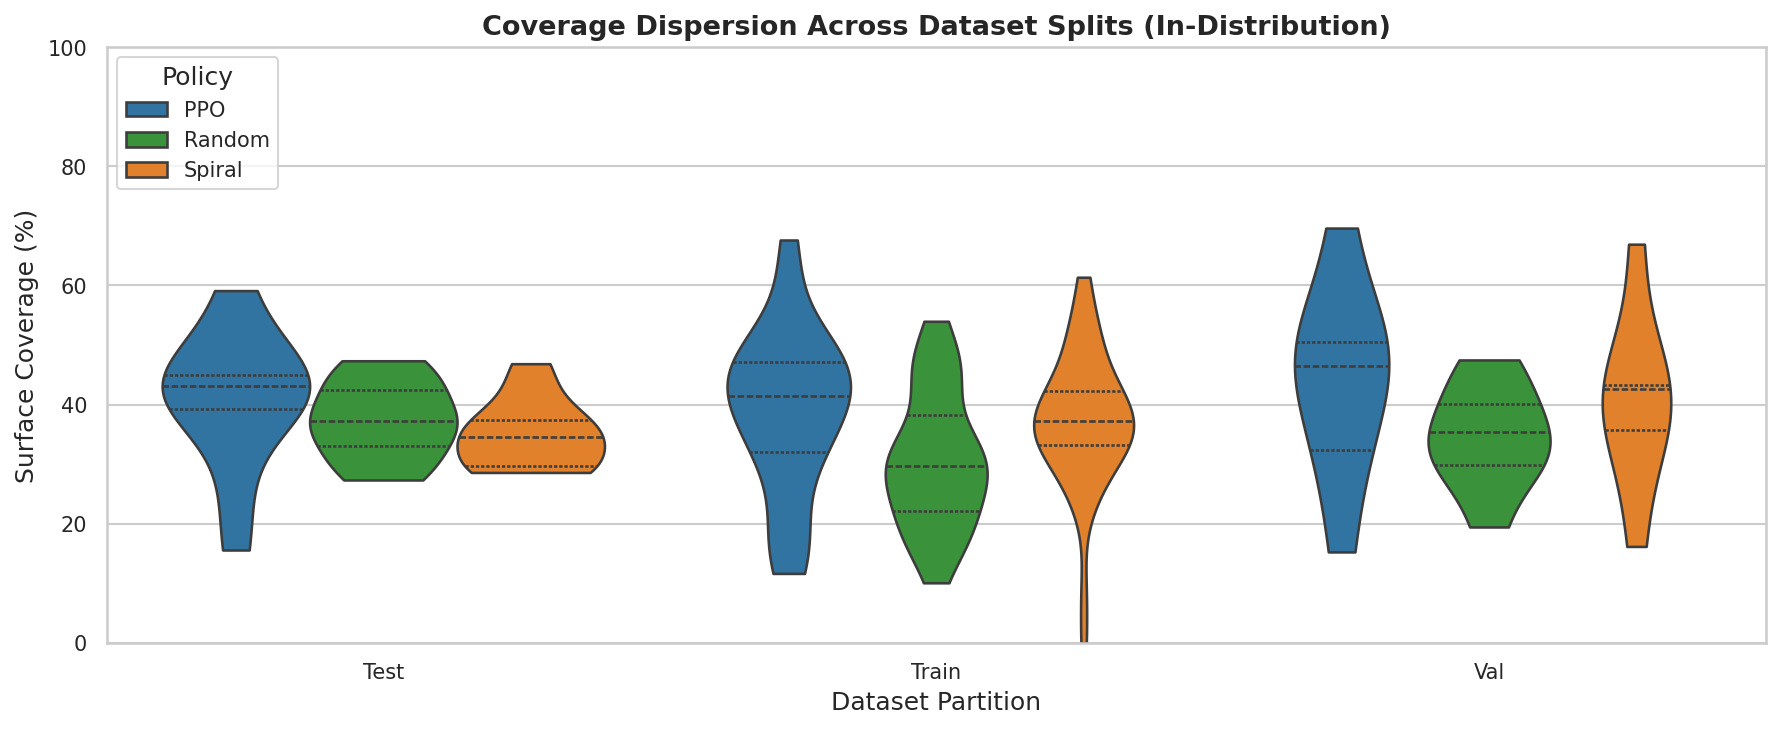

In [8]:
# 1. Model-by-Model Heatmap (In-Distribution Test Split)
indist_test_models = indist_final[indist_final["dataset_split"] == "Test"]
model_pivot = indist_test_models.pivot_table(index="model_name", columns="policy", values="coverage_pct").round(2)

plt.figure(figsize=(9, 7))
sns.heatmap(model_pivot, annot=True, fmt=".1f", cmap="YlGnBu", cbar_kws={'label': 'Surface Coverage (%)'})
plt.title("Per-Spacecraft Model Surface Coverage (In-Distribution Test Set)", fontweight="bold", pad=12)
plt.ylabel("Target Spacecraft CAD Model")
plt.xlabel("Policy")
plt.tight_layout()
plt.show()

# 2. Violin Plot of Performance Distributions Across Splits
plt.figure(figsize=(12, 5))
sns.violinplot(
    data=indist_final,
    x="dataset_split",
    y="coverage_pct",
    hue="policy",
    palette=POLICY_COLORS,
    cut=0,
    inner="quartile"
)
plt.title("Coverage Dispersion Across Dataset Splits (In-Distribution)", fontweight="bold")
plt.xlabel("Dataset Partition")
plt.ylabel("Surface Coverage (%)")
plt.ylim(0, 100)
plt.legend(title="Policy", loc="upper left")
plt.tight_layout()
plt.show()

---

## 8. 3D Spatial Viewpoint Trajectory Visualizations

We plot the 3D inspection trajectory around the chief spacecraft on the spherical inspection shell.

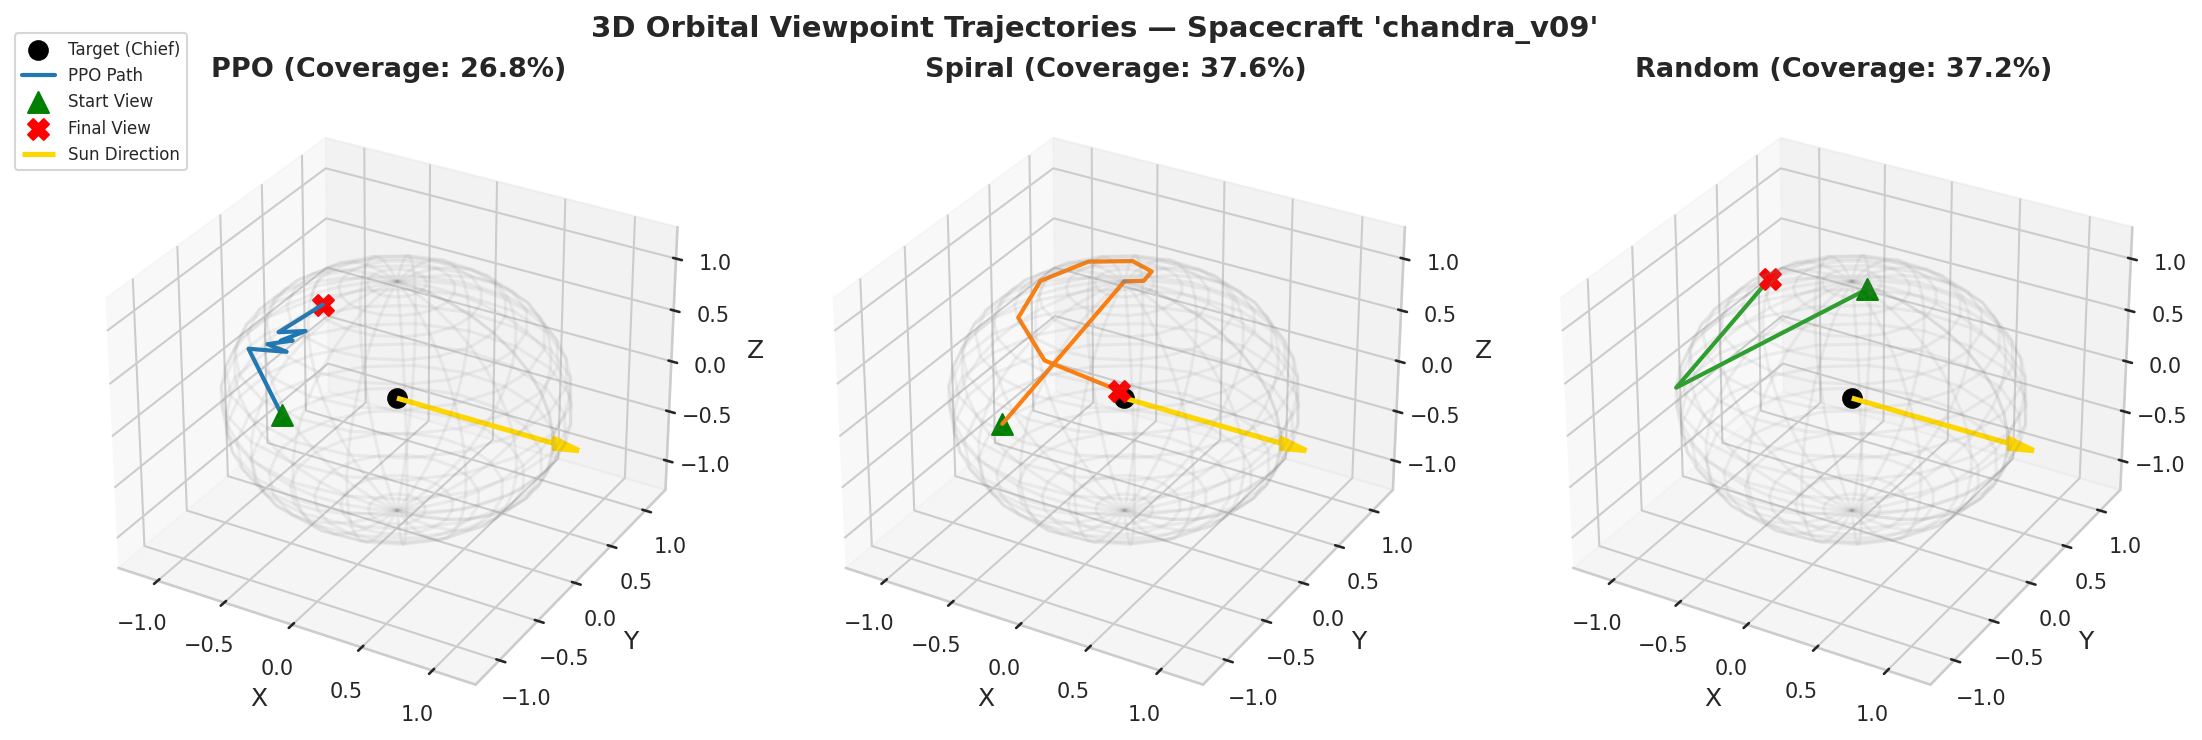

In [9]:
def plot_3d_inspection_trajectory(df_data, model_name, split="Test", config_name="InDist (100 m/s, 2 orbits, 30 steps)"):
    sub = df_data[
        (df_data["model_name"] == model_name) & 
        (df_data["dataset_split"] == split) & 
        (df_data["config_label"] == config_name)
    ]
    if sub.empty:
        print(f"No trajectory records for model '{model_name}'.")
        return
        
    fig = plt.figure(figsize=(15, 5))
    policies = [p for p in ["PPO", "Spiral", "Random"] if p in sub["policy"].unique()]
    
    for i, pol in enumerate(policies, 1):
        ax = fig.add_subplot(1, len(policies), i, projection='3d')
        pol_traj = sub[sub["policy"] == pol].sort_values("step")
        
        xs, ys, zs = pol_traj["camera_x"].values, pol_traj["camera_y"].values, pol_traj["camera_z"].values
        
        # Plot wireframe orbit sphere (R=1.12)
        u = np.linspace(0, 2 * np.pi, 20)
        v = np.linspace(0, np.pi, 20)
        sx = 1.12 * np.outer(np.cos(u), np.sin(v))
        sy = 1.12 * np.outer(np.sin(u), np.sin(v))
        sz = 1.12 * np.outer(np.ones(np.size(u)), np.cos(v))
        ax.plot_wireframe(sx, sy, sz, color="gray", alpha=0.1)
        
        # Plot target center
        ax.scatter([0], [0], [0], color="black", s=80, marker="o", label="Target (Chief)")
        
        # Plot trajectory path
        color = POLICY_COLORS.get(pol, "blue")
        ax.plot(xs, ys, zs, color=color, linewidth=2, label=f"{pol} Path")
        
        # Initial and Final Viewpoints
        if len(xs) > 0:
            ax.scatter([xs[0]], [ys[0]], [zs[0]], color="green", s=100, marker="^", label="Start View")
            ax.scatter([xs[-1]], [ys[-1]], [zs[-1]], color="red", s=100, marker="X", label="Final View")
            
        # Sun vector
        sun_x = pol_traj["sun_x"].iloc[0] if "sun_x" in pol_traj.columns else 1.0
        sun_y = pol_traj["sun_y"].iloc[0] if "sun_y" in pol_traj.columns else 0.0
        sun_z = pol_traj["sun_z"].iloc[0] if "sun_z" in pol_traj.columns else 0.0
        ax.quiver(0, 0, 0, sun_x*1.3, sun_y*1.3, sun_z*1.3, color="gold", linewidth=2.5, arrow_length_ratio=0.15, label="Sun Direction")
        
        cov_final = pol_traj["coverage_pct"].iloc[-1] if len(pol_traj) > 0 else 0.0
        ax.set_title(f"{pol} (Coverage: {cov_final:.1f}%)", fontweight="bold")
        ax.set_xlim([-1.3, 1.3])
        ax.set_ylim([-1.3, 1.3])
        ax.set_zlim([-1.3, 1.3])
        ax.set_xlabel("X")
        ax.set_ylabel("Y")
        ax.set_zlabel("Z")
        if i == 1:
            ax.legend(loc="upper left", bbox_to_anchor=(-0.1, 1.1), fontsize=8)
            
    plt.suptitle(f"3D Orbital Viewpoint Trajectories — Spacecraft '{model_name}'", fontsize=14, fontweight="bold", y=0.98)
    plt.tight_layout()
    plt.show()

# Plot representative spacecraft trajectory
plot_3d_inspection_trajectory(df, model_name="chandra_v09")

---

## 9. SB3 Training Diagnostics (Policy Entropy & Value Losses)

We parse training convergence metrics from `progress.csv` (or text log fallback).

In [10]:
sb3_log_csv = "artefacts/train/sb3_logs/progress.csv"
stdout_log = "container_stdout.log"

def load_sb3_training_progress(csv_p, text_p):
    if os.path.exists(csv_p):
        print(f"Loaded SB3 training metrics from CSV: '{csv_p}'")
        return pd.read_csv(csv_p)
    if os.path.exists(text_p):
        print(f"Parsing SB3 metrics from '{text_p}'...")
        records, rec = [], {}
        with open(text_p, "r", encoding="utf-8") as f:
            for line in f:
                match = re.search(r"\|\s+([\w\/]+)\s+\|\s+([-\d\.e+]+)\s+\|", line)
                if match:
                    k, v = match.group(1).strip(), float(match.group(2))
                    rec[k] = v
                if line.strip().startswith("---------------------------------") and rec:
                    if any(k in rec for k in ["time/total_timesteps", "train/approx_kl", "train/entropy_loss", "train/value_loss"]):
                        records.append(rec.copy())
                        rec = {}
        return pd.DataFrame(records)
    print("No training logs found.")
    return pd.DataFrame()

df_train_diag = load_sb3_training_progress(sb3_log_csv, stdout_log)

if not df_train_diag.empty:
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    x_axis = "time/total_timesteps" if "time/total_timesteps" in df_train_diag.columns else df_train_diag.index
    
    # 1. Policy Entropy
    if "train/entropy_loss" in df_train_diag.columns:
        axes[0].plot(df_train_diag[x_axis], -df_train_diag["train/entropy_loss"], color="purple", linewidth=2.0)
        axes[0].set_title("Policy Entropy (-entropy_loss)", fontweight="bold")
        axes[0].set_xlabel("Total Timesteps")
        axes[0].set_ylabel("Entropy")
    
    # 2. Approximate KL Divergence
    if "train/approx_kl" in df_train_diag.columns:
        axes[1].plot(df_train_diag[x_axis], df_train_diag["train/approx_kl"], color="teal", linewidth=2.0)
        axes[1].set_title("Approximate KL Divergence", fontweight="bold")
        axes[1].set_xlabel("Total Timesteps")
        axes[1].set_ylabel("Approx KL")
        
    # 3. Value Function Loss
    if "train/value_loss" in df_train_diag.columns:
        axes[2].plot(df_train_diag[x_axis], df_train_diag["train/value_loss"], color="crimson", linewidth=2.0)
        axes[2].set_title("Value Function Loss", fontweight="bold")
        axes[2].set_xlabel("Total Timesteps")
        axes[2].set_ylabel("Value Loss")
        
    plt.suptitle("PPO Training Diagnostics & Convergence Profile", fontsize=14, fontweight="bold", y=1.03)
    plt.tight_layout()
    plt.show()
else:
    print("Training log file not available in standard paths.")

No training logs found.
Training log file not available in standard paths.
